# Mean Reversion Out-of-Sample Test — Rolling OLS
In this notebook we test a cross-sectional mean reversion strategy on an unseen dataset spanning January 2025 to February 2026, using 4-hour crypto data across a universe of 70 assets.

### Strategy Overview

We use rolling OLS to regress each asset's returns against a market proxy, isolating the idiosyncratic component (the residual) by removing the common market factor. The strategy assumes this idiosyncratic component is mean reverting over short horizons — we go long assets that are underperforming relative to the market's prediction and short those that are overperforming. A dollar-neutral portfolio is constructed at each rebalance, ensuring the strategy has no net directional market exposure. Two smoothing mechanisms are applied to reduce turnover to a level viable at 20bps transaction costs: EWM smoothing of residuals before signal construction, and partial adjustment of portfolio weights.

### Parameter Selection

Parameters were selected via a grid search on the in-sample period (2022-2024), optimising for net Sharpe ratio. The optimal configuration uses ETH as the market proxy, a 30-day rolling window, rho of 0.95, alpha of 0.3, and a rank threshold of 0.10. These parameters are locked prior to out-of-sample evaluation and not adjusted.

### Out-of-Sample Results

The strategy achieves a gross Sharpe ratio of 0.87 and a net Sharpe ratio of -0.40 on the unseen dataset, indicating the strategy is no longer profitable after transaction costs in this period. The annualised cost drag of 12.9% against a gross return of only 8.8% highlights the core issue: the signal is too weak in this regime to overcome execution costs. The alpha t-statistic of 0.99 falls below the conventional significance threshold of 1.96, meaning we cannot reject the null hypothesis that alpha is zero in this period.

These results are consistent with the signal degradation observed towards the end of the in-sample period, suggesting the weakness that emerged from late 2023 onwards has persisted into the out-of-sample window. We attribute this primarily to ETH's significant underperformance relative to BTC and the broader altcoin market through 2025, as ETH decouples from the dominant market factor, the OLS residuals become contaminated by ETH-specific price action rather than purely reflecting idiosyncratic mean reversion. This motivates the use of PCA as an alternative approach, which adapts dynamically to the prevailing factor structure and demonstrates considerably stronger out-of-sample performance over the same period, as shown in the following notebook.


In [1]:
cd -q ../../

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest_oos
from src.backtest.helpers import sharpe
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [4]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)
px = px.loc["20240601":]

## Results of Out-of-sample Test

In [5]:
oos = run_backtest_oos(
    px, 
    freq="4h",
    rho=0.95, 
    rank_thresh=0.1,
    alpha=0.3, 
    mkt_ticker="ETHUSDT", 
    window_size=6*30, 
    method="ols",
    oos_start="2025-01-01"
    )

2026-03-05 01:49:14,433 INFO: Resampled to 4h


In [6]:
pd.DataFrame({x: y for x,y in oos.items() if type(y) is np.float64}, index=["oos"])

,avg_holding_days,gross_sharpe,net_sharpe,avg_ann,vol_ann,alpha_ann,alpha_tstat,beta,hit_rate,r_squared,avg_turnover,cost_drag_ann
oos,5.673881,0.872915,-0.398075,0.088304,0.10116,0.092476,0.988231,0.020606,0.50768,0.008396,0.029349,0.128548


The out-of-sample results for the OLS method reveal a significant deterioration in performance relative to the in-sample period. The gross Sharpe ratio falls to 0.87 and the net Sharpe ratio turns negative at -0.40, indicating the strategy is no longer profitable after transaction costs in this period. The annualised cost drag of 12.9% against a gross annualised return of only 8.8% highlights the fundamental challenge: the signal is too weak in this regime to overcome the cost of trading.
The alpha t-statistic of 0.99 is below the conventional significance threshold of 1.96, meaning we can no longer reject the null hypothesis that alpha is zero in the out-of-sample period. This contrasts sharply with the in-sample t-statistic of 4.00 and suggests the strategy's edge has materially weakened. Beta remains close to zero at 0.02, confirming the dollar-neutral construction continues to provide market neutrality even in adverse conditions.

The hit rate of 0.508 is barely above 0.5 (compared to 0.55 in-sample) indicating the signal has lost most of its directional predictability. Average turnover of 0.029 is consistent with the in-sample figure, suggesting the smoothing parameters are working as intended and the performance deterioration is driven by signal weakness rather than excessive trading. The average holding period of 5.7 days is also unchanged, confirming the portfolio construction is stable.
Taken together these results suggest the OLS mean reversion signal, while genuine in-sample, does not persist robustly out of sample under the bear market and rising correlation regime of late 2025. The PCA results discussed next demonstrate greater resilience over the same period.

### Information Coefficient (IC) Analysis

The following IC decay plot confirms the mean reversion signal found during our backtest persists out of sample.

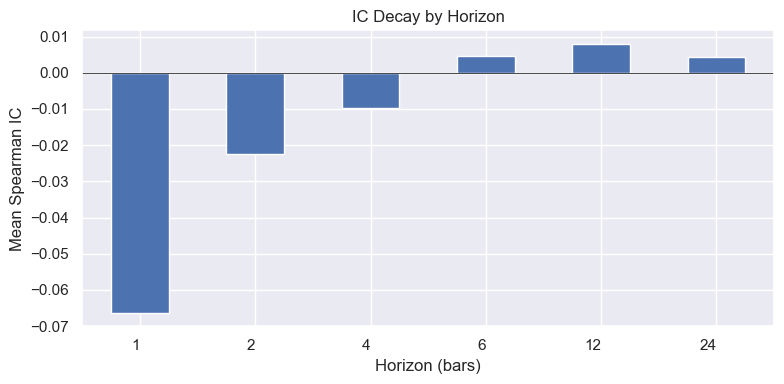

In [7]:
ic = oos["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling Net Sharpe Ratio

Performance is generally weak throughout the out-of-sample period, consistent with the negative net Sharpe ratio reported above. The rolling Sharpe deteriorates further towards the end of 2025, coinciding with the broader crypto bear market where rising cross-sectional correlation compresses the idiosyncratic return dispersion the strategy relies on. A tentative recovery is visible from the start of 2026, suggesting the signal may be reasserting itself as market conditions stabilise. However given the short duration of this recovery within the evaluation window, it is difficult to draw firm conclusions and further out-of-sample data would be needed to confirm whether this represents a genuine regime shift or a temporary fluctuation.

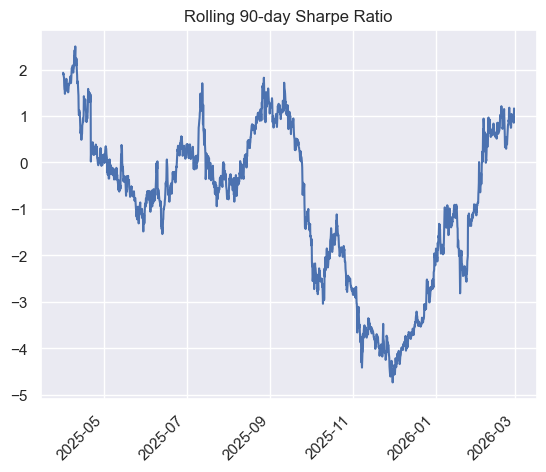

In [8]:
gross_ret = oos["gross_ret"]
net_ret = oos["net_ret"]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

Although our net cumulative returns are negative by the end of the out-of-sample period, they still outperform BTC buy-and-hold, which experiences significantly larger drawdowns under the bear market conditions prevailing from late 2025 onwards. This outperformance during a downturn is a direct consequence of the strategy's market-neutral construction: by maintaining approximately zero net market exposure (beta ≈ 0.02), the strategy avoids the directional losses that a passive BTC position incurs during bear market conditions.

However, the negative net cumulative return does indicate the strategy is regime sensitive. During bear markets, cross-sectional return dispersion tends to compress as assets fall together, reducing the idiosyncratic variation that the mean reversion signal relies on. This is consistent with the deterioration in rolling Sharpe ratio observed over the same period.

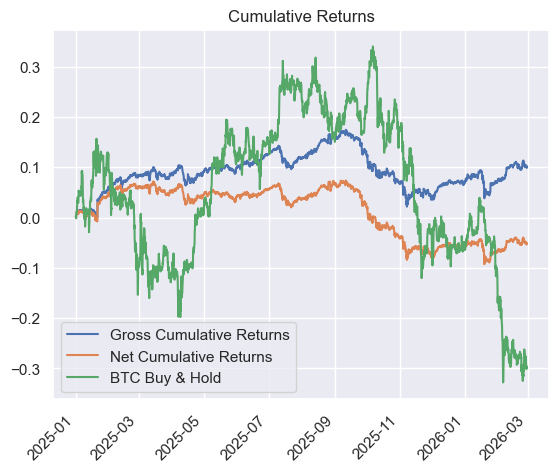

In [9]:
gross_cum = oos["gross_cum"]
net_cum = oos["net_cum"]

rets = rets.loc["20250101":]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Two extended drawdown periods are identified throughout the out-of-sample window. The first runs from March 2025 to September 2025, reflecting the period of weakest signal quality identified in the rolling Sharpe analysis. A second drawdown follows shortly after and persists through to the end of the testing period in February 2026, suggesting the strategy does not fully recover under the prevailing bear market conditions. The absence of a sustained recovery period between the two drawdowns is concerning and consistent with the near-zero hit rate of 0.508 observed over this window, i.e. the signal has insufficient directional predictability to generate the winning trades needed to offset drawdown periods.

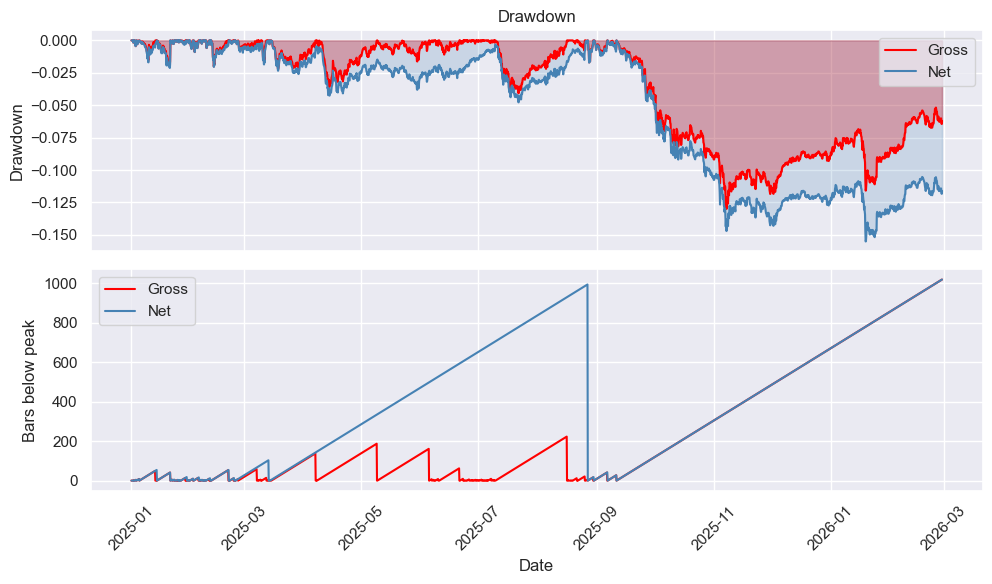

In [10]:
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

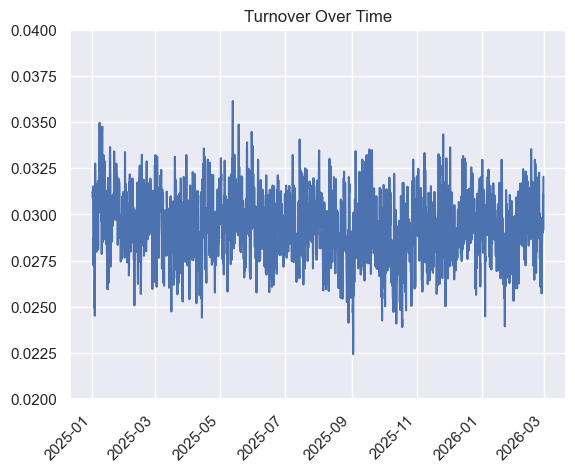

In [11]:
to = oos["to"]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.02, 0.04)
plt.show()

In the following, we show that, although turnover remains similar to that seen previously, our strategy is unprofitable at this time period with the 20bps assumption. We see that even at 15bps, the strategy becomes marginally unprofitable with a net Sharpe of -0.08. This suggests this strategy is unviable within the crypto universe for a taker strategy.

In [12]:
for bps in [5, 10, 15, 20]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

  5bps: net Sharpe = 0.56
 10bps: net Sharpe = 0.24
 15bps: net Sharpe = -0.08
 20bps: net Sharpe = -0.40
